In [45]:
import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.typings import LayerSpec
from ihp import PDK

PDK.activate()

c = gf.import_gds("~/Documents/gsim/nbs/inductors/stacked_transformer.gds")

2026-06-19 14:42:40.826 | ERROR    | kfactory.kcell:name:688 - Name conflict in kfactory.kcell::name at line 688
Renaming Unnamed_12 (cell_index=12) to StackedTransformer would cause it to be named the same as:
 - StackedTransformer (cell_index=0), function_name=None, basename=None


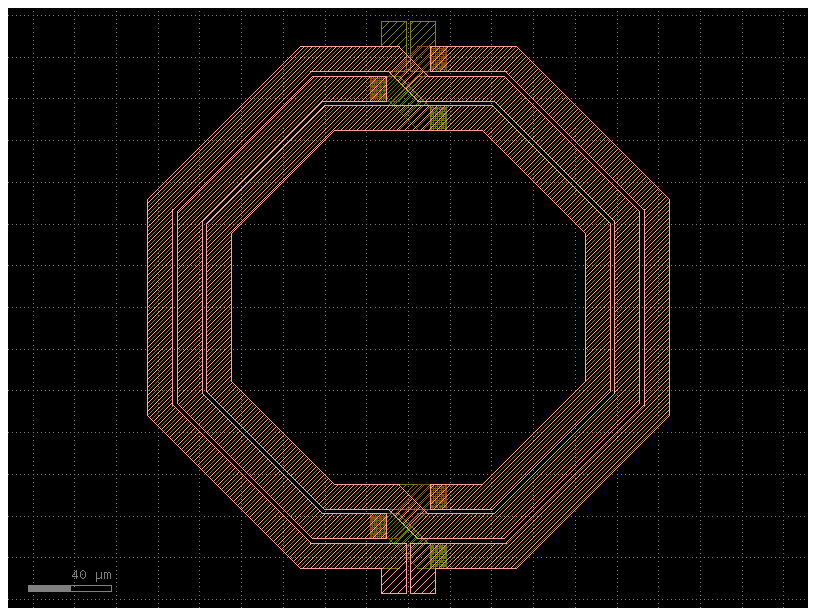

In [46]:
c.plot()

In [47]:
from __future__ import annotations
import math
from primitives import (
    Poly,
    _zip,
    mirror_y,
    routing_geometric_45,
    via_grid,
)

In [48]:
def _build_winding_polygons(cfg: dict) -> tuple[dict[str, list[Poly]], list[dict]]:
    """Calculates polygon coordinates and native gdsfactory port definitions."""
    N = cfg["N"]
    sides = cfg["sides"]
    width = cfg["width"]
    spacing = cfg["spacing"]
    Dout = cfg["Dout"]
    R1_start = cfg["R1_start"]
    center_tap = cfg["center_tap"]
    extend = cfg["via_extent"]
    via_spacing = cfg["via_spacing"]
    via_width = cfg["via_width"]
    via_in_metal = cfg["via_in_metal"]
    winding_layer = cfg["windingLayer"]
    crossing_layer = cfg["crossingLayer"]
    via_layer = cfg["viaLayer"]
    port_side = cfg["portSide"]

    PI = math.pi
    SQRT2 = math.sqrt(2)
    v = width / math.cos(PI / sides)
    s = (spacing + width) / math.cos(PI / sides)
    sep_total = width + spacing + (SQRT2 - 1) * (2 * spacing + width)

    n_half = sides // 2
    left_angles = [PI * (0.5 + (i + 0.5) * 2 / sides) for i in range(n_half)]
    right_angles = [PI * (-0.5 + (i + 0.5) * 2 / sides) for i in range(n_half)]

    pw: list[Poly] = []
    pc: list[Poly] = []
    pct: list[Poly] = []
    pv: list[Poly] = []
    pv2: list[Poly] = []

    R1 = R1_start
    R2 = R1 - v
    for winding in range(N):
        for angles, left in ((left_angles, True), (right_angles, False)):
            x_out = [R1 * math.cos(p) for p in angles]
            y_out = [R1 * math.sin(p) for p in angles]
            x_in = [R2 * math.cos(p) for p in angles]
            y_in = [R2 * math.sin(p) for p in angles]

            if winding == N - 1:
                if left:
                    if N % 2 == 0:
                        x_out = [-sep_total / 2, *x_out, 0]
                        x_in = [-sep_total / 2, *x_in, 0]
                    else:
                        x_out = [0, *x_out, -sep_total / 2]
                        x_in = [0, *x_in, -sep_total / 2]
                else:
                    if N % 2 == 0:
                        x_out = [0, *x_out, sep_total / 2]
                        x_in = [0, *x_in, sep_total / 2]
                    else:
                        x_out = [sep_total / 2, *x_out, 0]
                        x_in = [sep_total / 2, *x_in, 0]
            else:
                sgn = -1 if left else 1
                x_out = [sgn * sep_total / 2, *x_out, sgn * sep_total / 2]
                x_in = [sgn * sep_total / 2, *x_in, sgn * sep_total / 2]

            y_out = [y_out[0], *y_out, y_out[-1]]
            y_in = [y_in[0], *y_in, y_in[-1]]
            pw.append(_zip([*x_out, *reversed(x_in)], [*y_out, *reversed(y_in)]))

        if winding != N - 1:
            h = (
                R1 * math.sin(PI * (0.5 - 1 / sides))
                if winding % 2 == 0
                else (-R2 + s) * math.sin(PI * (0.5 - 1 / sides))
            )

            pc.append(
                routing_geometric_45(width, spacing, 0, h - width - spacing / 2, extend)
            )
            ct = routing_geometric_45(width, spacing, 0, h - width - spacing / 2, 0)
            pw.append([(-x, y) for (x, y) in ct])

            for cx, cy in [
                (-sep_total / 2 - width / 2, h - 3 * width / 2 - spacing),
                (sep_total / 2 + width / 2, h - width / 2),
            ]:
                dx = math.copysign(1, cx) * (extend - width) / 2
                pv += via_grid(
                    cx + dx,
                    cy,
                    extend - 2 * via_in_metal,
                    width - 2 * via_in_metal,
                    via_spacing,
                    via_width,
                )

        R1 -= s
        R2 -= s

    if center_tap:
        x_ct = [-width / 2, -width / 2, width / 2, width / 2]
        if N % 2 != 0:
            if N <= 2:
                y_ct = [
                    -Dout / 2,
                    Dout / 2 - spacing * (N - 1) - width * (N - 1),
                    Dout / 2 - spacing * (N - 1) - width * (N - 1),
                    -Dout / 2,
                ]
            else:
                y_ct = [
                    -Dout / 2 + width - extend,
                    Dout / 2 - spacing * (N - 1) - width * (N - 1) - extend,
                    Dout / 2 - spacing * (N - 1) - width * (N - 1) - extend,
                    -Dout / 2 + width - extend,
                ]
        else:
            if N <= 2:
                y_ct = [
                    -Dout / 2,
                    -Dout / 2 + spacing * (N - 1) + width * (N - 1),
                    -Dout / 2 + spacing * (N - 1) + width * (N - 1),
                    -Dout / 2,
                ]
            else:
                y_ct = [
                    -Dout / 2 + width - extend,
                    -Dout / 2 + spacing * (N - 1) + width * (N - 1),
                    -Dout / 2 + spacing * (N - 1) + width * (N - 1),
                    -Dout / 2 + width - extend,
                ]

        if N <= 2:
            pw.append(_zip(x_ct, y_ct))
        else:
            pct.append(_zip(x_ct, y_ct))
            if N % 2 != 0:
                x_ct1, y_ct1 = (
                    0,
                    Dout / 2 - spacing * (N - 1) - width * (N - 1) - extend / 2,
                )
                x_ct2, y_ct2 = 0, -Dout / 2 + width / 2 + (width - extend) / 2
            else:
                x_ct1, y_ct1 = (
                    0,
                    -Dout / 2 + spacing * (N - 1) + width * N - width + extend / 2,
                )
                x_ct2, y_ct2 = 0, -Dout / 2 + width - extend / 2

            xvp1 = [
                x_ct1 - width / 2,
                x_ct1 - width / 2,
                x_ct1 + width / 2,
                x_ct1 + width / 2,
            ]
            yvp1 = [
                y_ct1 - extend / 2,
                y_ct1 + extend / 2,
                y_ct1 + extend / 2,
                y_ct1 - extend / 2,
            ]
            xvp2 = [
                x_ct2 - width / 2,
                x_ct2 - width / 2,
                x_ct2 + width / 2,
                x_ct2 + width / 2,
            ]
            yvp2 = [
                y_ct2 - extend / 2,
                y_ct2 + extend / 2,
                y_ct2 + extend / 2,
                y_ct2 - extend / 2,
            ]

            pw.append(_zip(xvp1, yvp1))
            pc.append(_zip(xvp1, yvp1))
            pct.append(_zip(xvp1, yvp1))
            pc.append(_zip(xvp2, yvp2))
            pct.append(_zip(xvp2, yvp2))

            for cx, cy in [(x_ct1, y_ct1), (x_ct2, y_ct2)]:
                vp = via_grid(
                    cx,
                    cy,
                    width - 2 * via_in_metal,
                    extend - 2 * via_in_metal,
                    via_spacing,
                    via_width,
                )
                pv2 += vp
                pv += vp

    # Base port shapes
    ps = cfg.get("portSpacing") or spacing
    pxo = ps + width if center_tap else (ps + width) / 2
    x_port = [
        -sep_total / 2,
        -pxo + width / 2,
        -pxo + width / 2,
        -pxo - width / 2,
        -pxo - width / 2,
        -sep_total / 2,
    ]
    y_port = [
        -Dout / 2 + width,
        -Dout / 2 + width,
        -Dout / 2 - width,
        -Dout / 2 - width,
        -Dout / 2,
        -Dout / 2,
    ]

    if center_tap:
        pw.append(
            _zip(
                [-width / 2, -width / 2, width / 2, width / 2],
                [
                    -Dout / 2 - width,
                    -Dout / 2 + width,
                    -Dout / 2 + width,
                    -Dout / 2 - width,
                ],
            )
        )

    pw.append(_zip(x_port, y_port))
    pw.append(_zip([-x for x in x_port], y_port))

    # Apply mirroring if the winding targets the top side
    all_groups = [pw, pc, pct, pv, pv2]
    if port_side == "top":
        all_groups = [[mirror_y(p) for p in g] for g in all_groups]
        pw, pc, pct, pv, pv2 = all_groups

    layers: dict[str, list[Poly]] = {}
    if pw:
        layers[winding_layer] = pw
    if pc:
        layers[crossing_layer] = pc
    if pv:
        layers[via_layer] = pv
    if pct:
        layers["centertap"] = pct
    if pv2:
        layers["vias2" if via_layer == "vias1" else "vias1"] = pv2

    # Formatting ports natively for gdsfactory (Fixed outer_diameter to Dout)
    port_y = Dout / 2 + width if port_side == "top" else -Dout / 2 - width
    orientation = 90.0 if port_side == "top" else 270.0

    ports = [
        {
            "name": "P1",
            "center": (-pxo, port_y),
            "width": width,
            "orientation": orientation,
            "layer_key": winding_layer,
        },
        {
            "name": "P2",
            "center": (pxo, port_y),
            "width": width,
            "orientation": orientation,
            "layer_key": winding_layer,
        },
    ]
    if center_tap:
        ports.append(
            {
                "name": "CT",
                "center": (0, port_y),
                "width": width,
                "orientation": orientation,
                "layer_key": winding_layer,
            }
        )

    return layers, ports

In [49]:
gf.cell


def stacked_transformer(
    outer_diameter: float = 130.0,
    primary_turns: int = 3,
    secondary_turns: int = 3,
    sides: int = 8,
    width: float = 10.0,
    spacing: float = 4.0,
    center_tap_primary: bool = False,
    center_tap_secondary: bool = False,
    via_extent: float = 2.0,
    via_spacing: float = 0.8,
    via_width: float = 1.0,
    via_in_metal: float = 0.45,
    port_spacing: float | None = None,
    layer_windings_m4: LayerSpec = "TopMetal2drawing",
    layer_windings: LayerSpec = "TopMetal1drawing",
    layer_vias3: LayerSpec = "TopVia2drawing",
    layer_windings_m2: LayerSpec = "Metal4drawing",
    layer_crossings_m1: LayerSpec = "Metal3drawing",
    layer_vias2: LayerSpec = "Via3drawing",
    layer_centertap: LayerSpec = "TopMetal1drawing",
    layer_vias1: LayerSpec = "Via2drawing",
) -> Component:
    """Stacked differential transformer for RF applications.

    Constructs a primary winding on upper metal layers and a secondary winding
    on lower metal layers, stacked vertically. The primary ports exit at the
    bottom, and the secondary ports exit at the top.

    Args:
        outer_diameter: Outer bounding diameter of the transformer in micrometers.
        primary_turns: Number of complete turns for the primary winding.
        secondary_turns: Number of complete turns for the secondary winding.
        sides: Number of polygon sides per turn (8 = octagonal).
        width: Metal trace width in micrometers.
        spacing: Gap between adjacent turns in micrometers.
        center_tap_primary: Add a center-tap port (CT_P) to the primary winding.
        center_tap_secondary: Add a center-tap port (CT_S) to the secondary winding.
        via_extent: Height of the via landing pad in micrometers.
        via_spacing: Gap between individual via squares.
        via_width: Side length of each via square.
        via_in_metal: Minimum metal enclosure around each via.
        port_spacing: Gap between the signal ports. Defaults to inter-turn spacing.
        layer_primary_winding: Main metal layer for the primary coil.
        layer_primary_underpass: Metal layer for the primary crossings.
        layer_primary_via: Via layer connecting primary winding and underpass.
        layer_primary_via_ct: Optional dedicated via layer for primary center-tap drops.
        layer_secondary_winding: Main metal layer for the secondary coil.
        layer_secondary_underpass: Metal layer for the secondary crossings.
        layer_secondary_via: Via layer connecting secondary winding and underpass.
        layer_secondary_via_ct: Optional dedicated via layer for secondary center-tap drops.

    Returns:
        Component with up to 6 ports:
          P+   -> Primary positive terminal (bottom)
          P-   -> Primary negative terminal (bottom)
          CT_P -> Primary center tap (bottom)
          S+   -> Secondary positive terminal (top)
          S-   -> Secondary negative terminal (top)
          CT_S -> Secondary center tap (top)
    """
    c = Component()

    # Setup shared calculations for the math helper
    R1_init = outer_diameter / 2 / math.cos(math.pi / sides)
    common = dict(
        sides=sides,
        width=width,
        spacing=spacing,
        Dout=outer_diameter,
        R1_start=R1_init,
        via_extent=via_extent,
        via_spacing=via_spacing,
        via_width=via_width,
        via_in_metal=via_in_metal,
        portSpacing=port_spacing,
    )

    # Calculate Primary and Secondary geometries
    prim_layers, prim_ports = _build_winding_polygons(
        {
            **common,
            "N": primary_turns,
            "center_tap": center_tap_primary,
            "windingLayer": "windings_m4",
            "crossingLayer": "windings",
            "viaLayer": "vias3",
            "portSide": "bottom",
        }
    )

    sec_layers, sec_ports = _build_winding_polygons(
        {
            **common,
            "N": secondary_turns,
            "center_tap": center_tap_secondary,
            "windingLayer": "windings_m2",
            "crossingLayer": "crossings_m1",
            "viaLayer": "vias2",
            "portSide": "top",
        }
    )

    # Map the internal string keys to actual gdsfactory LayerSpecs
    layer_map = {
        "windings_m4": layer_windings_m4,
        "windings": layer_windings,
        "vias3": layer_vias3,
        "windings_m2": layer_windings_m2,
        "crossings_m1": layer_crossings_m1,
        "vias2": layer_vias2,
        "centertap": layer_centertap,
        "vias1": layer_vias1,
    }

    # Add all polygons to the component
    for src in (prim_layers, sec_layers):
        for layer_key, polys in src.items():
            gf_layer = layer_map.get(layer_key)
            if gf_layer:
                for poly in polys:
                    c.add_polygon(poly, layer=gf_layer)

    # Add and map the primary ports
    prim_name_map = {"P1": "P+", "P2": "P-", "CT": "CT_P"}
    for p in prim_ports:
        gf_layer = layer_map.get(p["layer_key"])
        if gf_layer:
            new_name = prim_name_map.get(p["name"], p["name"])
            c.add_port(
                new_name,
                center=p["center"],
                width=p["width"],
                orientation=p["orientation"],
                layer=gf_layer,
            )

    # Add and map the secondary ports
    sec_name_map = {"P1": "S+", "P2": "S-", "CT": "CT_S"}
    for p in sec_ports:
        gf_layer = layer_map.get(p["layer_key"])
        if gf_layer:
            new_name = sec_name_map.get(p["name"], p["name"])
            c.add_port(
                new_name,
                center=p["center"],
                width=p["width"],
                orientation=p["orientation"],
                layer=gf_layer,
            )

    return c

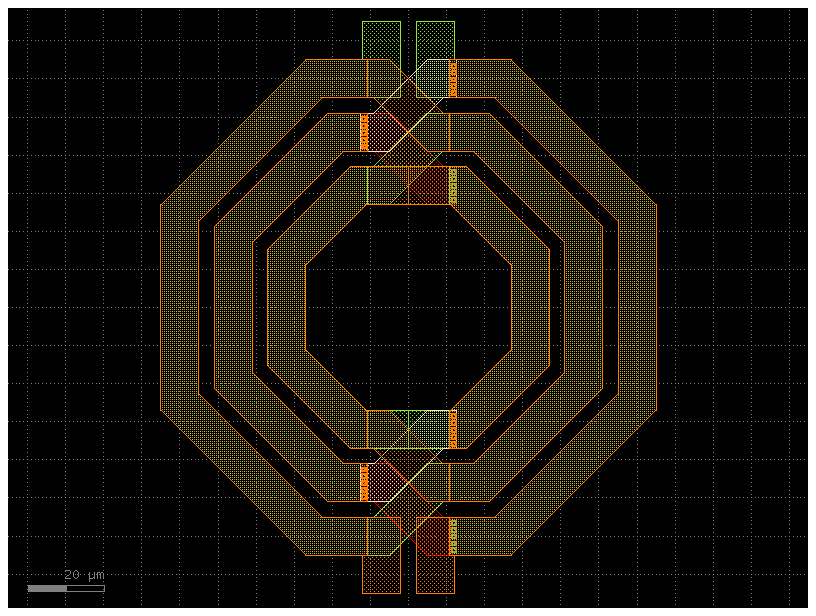

In [50]:
cc = stacked_transformer()
cc.plot()

In [51]:
cc.ports

["Port(self.name='P+', self.width=10000, trans=r270 *1 -7,-75, layer=TopMetal2drawing (134/0), port_type=optical)", "Port(self.name='P-', self.width=10000, trans=r270 *1 7,-75, layer=TopMetal2drawing (134/0), port_type=optical)", "Port(self.name='S+', self.width=10000, trans=r90 *1 -7,75, layer=Metal4drawing (50/0), port_type=optical)", "Port(self.name='S-', self.width=10000, trans=r90 *1 7,75, layer=Metal4drawing (50/0), port_type=optical)"]

In [54]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-stacked_transformer")

# Set the component geometry
sim.set_geometry(cc)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=180.0, include_substrate=True)

# Configure ports
sim.add_port("P+", layer="topmetal2", geometry="inplane", excited=True)
sim.add_port("P-", layer="topmetal2", geometry="inplane", excited=True)
sim.add_port("S+", layer="metal4", geometry="inplane", excited=True)
sim.add_port("S-", layer="metal4", geometry="inplane", excited=True)
# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=10e9, fmax=200e9, num_points=50)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [55]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.set_airbox(margin_x=50, margin_y=50, z_above=50, z_below=5)
sim.mesh(preset="default", refined_mesh_size=1.5)
sim.write_config()

Info    : Reading 'palace-sim-stacked_transformer/palace.msh'...
Info    : 38914 nodes
Info    : 285450 elements
Info    : Done reading 'palace-sim-stacked_transformer/palace.msh'                                               
Info    : Reading 'palace-sim-stacked_transformer/palace.msh'...
Info    : 38914 nodes
Info    : 285450 elements
Info    : Done reading 'palace-sim-stacked_transformer/palace.msh'                                               
Info    : Reading 'palace-sim-stacked_transformer/palace.msh'...
Info    : 38914 nodes
Info    : 285450 elements
Info    : Done reading 'palace-sim-stacked_transformer/palace.msh'                                               
Info    : Reading 'palace-sim-stacked_transformer/palace.msh'...
Info    : 38914 nodes
Info    : 285450 elements
Info    : Done reading 'palace-sim-stacked_transformer/palace.msh'                                               


PosixPath('palace-sim-stacked_transformer/config.json')

In [57]:
sim.plot_mesh(show_groups=["metal", "via", "P"])

Widget(value='<iframe src="http://localhost:34581/index.html?ui=P_0x728f11caeb40_1&reconnect=auto" class="pyvi…